# Exploring UKCA StratTrop reaction kinetics

This notebook uses the reaction data from Archibald et al. (2020, *GMD*), Supplementary Information Tables S1-S8, to let you compute and plot rate coefficients.

Data source: https://doi.org/10.5194/gmd-13-1223-2020-supplement

Make sure `kinetics.py` and the `data/` folder are in the same directory as this notebook.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../assets/kinetic_data'))  # repo layout: notebooks/ -> assets/kinetic_data/

import numpy as np
import matplotlib.pyplot as plt
import kinetics as kin

s1 = kin.load_table('S1')  # bimolecular reactions
s2 = kin.load_table('S2')  # termolecular reactions
s1.head()

,reactants,products,A,alpha,neg_Ea_R,water_or_pressure_dependent
0,Br + Cl2O2,BrCl + Cl + O2,5.900000e-12,0.0,170,NaN
1,Br + HCHO,HBr + CO + HO2,1.700000e-11,0.0,800,NaN
2,Br + HO2,HBr + O2,4.800000e-12,0.0,310,NaN
3,Br + O3,BrO + O2,1.600000e-11,0.0,780,NaN
4,Br + OClO,BrO + ClO,2.600000e-11,0.0,1300,NaN


## 1. Plot k(T) for a bimolecular reaction

Pick any reaction from Table S1 (see the `reactants` column, e.g. `'OH + CH4'`, `'Cl + O3'`, `'BrO + NO'`). If a reaction appears more than once (branching), use `which=0,1,...` to select a branch.

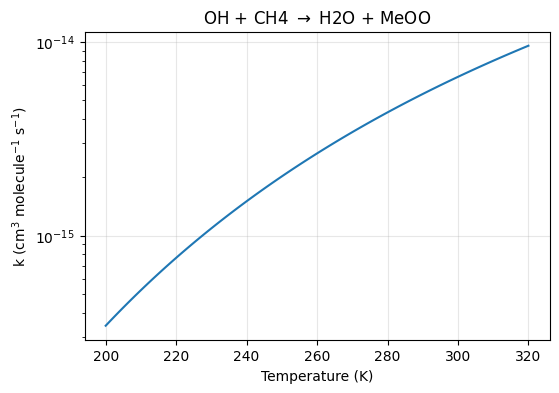

In [2]:
T = np.linspace(200, 320, 100)  # K, typical tropo/strato range

reaction = 'OH + CH4'
k, row = kin.k_from_table_S1(s1, reaction, T)

plt.figure(figsize=(6,4))
plt.plot(T, k)
plt.xlabel('Temperature (K)')
plt.ylabel('k (cm$^3$ molecule$^{-1}$ s$^{-1}$)')
plt.title(f"{row['reactants']} $\\rightarrow$ {row['products']}")
plt.yscale('log')
plt.grid(alpha=0.3)
plt.show()

## 2. Standard atmosphere: altitude -> T, P, number density

`kinetics.standard_atmosphere(z_m)` implements a simplified 1976 US Standard Atmosphere (0-86 km) so you can convert an altitude profile into temperature and air number density [M].

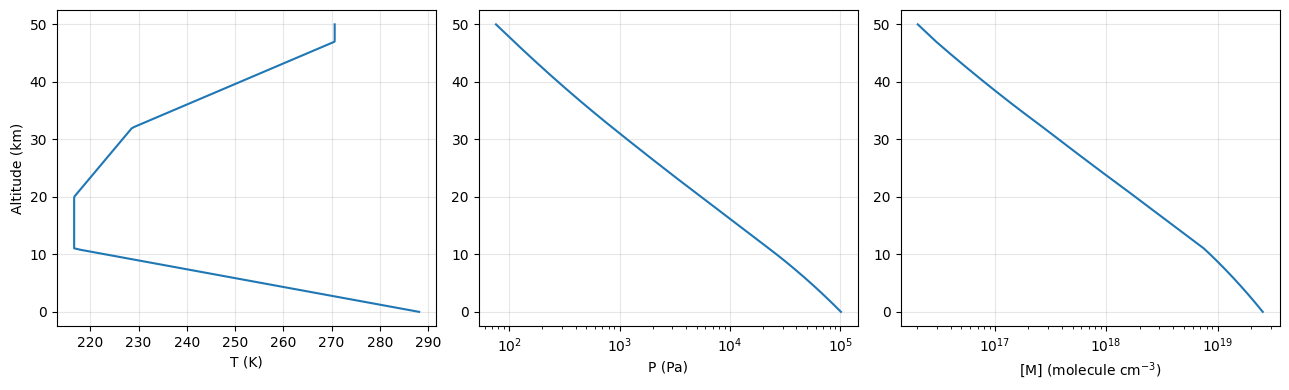

In [3]:
z_km = np.linspace(0, 50, 200)
T_z, P_z, M_z = kin.standard_atmosphere(z_km * 1000)

fig, axes = plt.subplots(1, 3, figsize=(13,4))
axes[0].plot(T_z, z_km); axes[0].set_xlabel('T (K)'); axes[0].set_ylabel('Altitude (km)')
axes[1].plot(P_z, z_km); axes[1].set_xlabel('P (Pa)'); axes[1].set_xscale('log')
axes[2].plot(M_z, z_km); axes[2].set_xlabel('[M] (molecule cm$^{-3}$)'); axes[2].set_xscale('log')
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Plot k as a function of altitude for a *termolecular* (pressure-dependent) reaction

This is the interesting case: termolecular rate coefficients depend on both T and [M], both of which vary with altitude. Try `'OH + NO2'`, `'ClO + ClO'`, `'NO2 + NO3'` (N2O5 formation), etc. — see Table S2 for the full list.

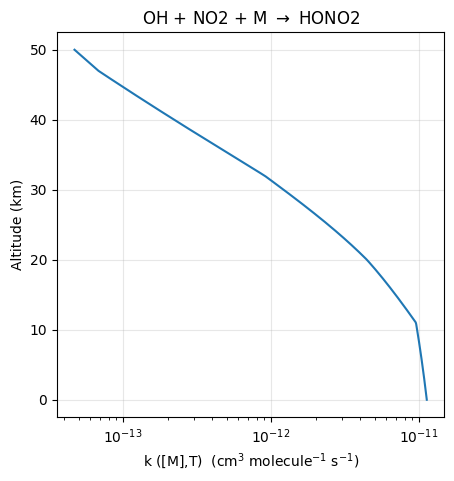

In [4]:
reaction2 = 'OH + NO2'
k_alt, row2 = kin.k_from_table_S2(s2, reaction2, T_z, M_z)

plt.figure(figsize=(5,5))
plt.plot(k_alt, z_km)
plt.xlabel('k ([M],T)  (cm$^3$ molecule$^{-1}$ s$^{-1}$)')
plt.ylabel('Altitude (km)')
plt.title(f"{row2['reactants']} + M $\\rightarrow$ {row2['products']}")
plt.xscale('log')
plt.grid(alpha=0.3)
plt.show()

## 4. Compare the low-pressure vs high-pressure limits

A nice teaching point: near the surface (~1000 hPa) termolecular reactions sit close to their high-pressure limit k2; in the upper stratosphere/mesosphere they fall to the low-pressure limit k1[M]. Try re-running cell 3 with `'ClO + ClO'` (important for the polar ozone hole - Cl2O2 formation) and note how the shape of k(altitude) changes compared to `'OH + NO2'`.

## 5. Effective Henry's law constant vs temperature (Tables S6-S8)

Example: H2O2, an important aqueous-phase oxidant of SO2 (see SI Section 2.2).

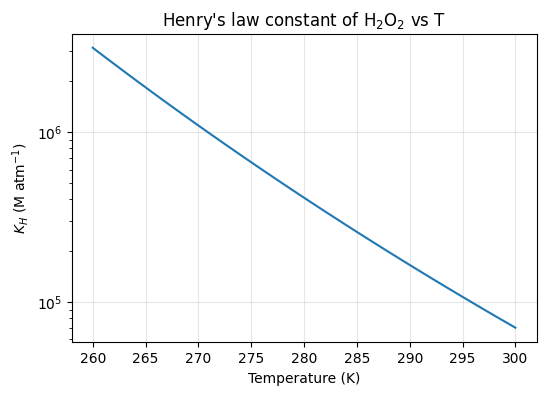

In [5]:
s6 = kin.load_table('S6')
row6 = s6[s6['species'] == 'H2O2'].iloc[0]

T_range = np.linspace(260, 300, 100)
KH = kin.henry_constant(row6['KH_298K_M_atm-1'], row6['neg_dH_R_K'], T_range)

plt.figure(figsize=(6,4))
plt.plot(T_range, KH)
plt.xlabel('Temperature (K)')
plt.ylabel('$K_H$ (M atm$^{-1}$)')
plt.title('Henry\'s law constant of H$_2$O$_2$ vs T')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.show()

## Ideas for student exercises

1. Plot k(T) for all three OH + O3, Cl + O3, and Br + O3 reactions on the same axes (log scale) to compare halogen ozone-destruction efficiency.
2. For a termolecular reaction, plot the ratio $k([M],T)/k_2(T)$ vs altitude to see where the reaction transitions from low- to high-pressure-limited behaviour.
3. Using Table S5's explicit rate expressions, plot the aqueous-phase oxidation rate of HSO3- by H2O2 vs T and compare to the ozone pathway.
4. Using Table S6-S8, rank species by their effective Henry's law constant at 275 K (a typical cloud temperature) to discuss which species partition most strongly into cloud water.